<a href="https://colab.research.google.com/github/liad3003/EDA_PROJECT/blob/main/LiadDabach207266081.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression and Classification: Error Analysis
**Dataset:** 5-Year NBA Rookie Classification Dataset (rookie season box-score stats, 1,340 players)

## Setup and K-Fold Justification
All analyses in this assignment are conducted using $k$-fold cross-validation.

**Justification for $k=5$:** The dataset contains approximately 1,340 rookie records. With a dataset of
this size, a very large $k$ (e.g. $k=10$ or higher) would shrink each validation fold to very few
samples, making error estimates noisier (higher variance), while a very small $k$ (e.g. $k=2$ or $3$)
would shrink the training set too much and increase bias. $k=5$ gives each training fold about 80% of
the data (roughly 1,070 rows, enough to fit stable models) while each validation fold still has roughly
268 rows, which is enough to get a reasonably stable estimate of the error. $k=5$ is therefore a
standard, well-justified balance point of the bias-variance trade-off for a dataset of this size,
without excessive computational cost.

In [1]:
# Upload the dataset CSV (nba_logreg.csv from the "5-Year NBA Rookie Classification" Kaggle dataset)
# https://www.kaggle.com/datasets/mexwell/5-year-nba-rookie-classification
from google.colab import files
uploaded = files.upload()  # select nba_logreg.csv when prompted


Saving nba_logreg.csv to nba_logreg.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_fscore_support, matthews_corrcoef)
from scipy.stats import skew, kurtosis

# --- Load Data ---
# Column names in nba_logreg.csv:
# Name, GP, MIN, PTS, FGM, FGA, FG%, 3P Made, 3PA, 3P%, FTM, FTA, FT%, OREB, DREB, REB, AST, STL, BLK, TOV, TARGET_5Yrs
df = pd.read_csv('nba_logreg.csv')
df.columns = df.columns.str.strip()  # guard against stray whitespace in headers

# The Kaggle CSV ships with lowercase, underscore-separated column names
# (e.g. 'gp', 'min', 'fg', '3p_made') instead of the original 'GP', 'MIN', 'FG%', '3P Made'.
# Rename them here to the canonical names used throughout the rest of this notebook,
# so nothing downstream needs to change.
column_rename_map = {
    'name': 'Name', 'gp': 'GP', 'min': 'MIN', 'pts': 'PTS',
    'fgm': 'FGM', 'fga': 'FGA', 'fg': 'FG%',
    '3p_made': '3P Made', '3pa': '3PA', '3p': '3P%',
    'ftm': 'FTM', 'fta': 'FTA', 'ft': 'FT%',
    'oreb': 'OREB', 'dreb': 'DREB', 'reb': 'REB',
    'ast': 'AST', 'stl': 'STL', 'blk': 'BLK', 'tov': 'TOV',
    'target_5yrs': 'TARGET_5Yrs'
}
df = df.rename(columns=column_rename_map)
print("Columns after rename:", df.columns.tolist())

# ============================================================
# Preprocessing for REGRESSION: Predicting Points Per Game (PTS)
# ============================================================
# We predict PTS (scoring output) from playing-time and volume/efficiency stats.
# NOTE: FGM, 3P Made and FTM are dropped from the features on purpose -- they are
# the literal scoring components used to compute PTS, so including them would leak
# the target almost perfectly. FG%, 3P%, FT% are efficiency ratios and are kept.
reg_features = ['GP', 'MIN', 'FGA', 'FG%', '3PA', '3P%', 'FTA', 'FT%',
                 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV']
df_reg = df[reg_features + ['PTS']].dropna()
X_reg = df_reg[reg_features]
y_reg = df_reg['PTS']

# ============================================================
# Preprocessing for CLASSIFICATION: Predicting 5-Year Career Longevity
# ============================================================
# Target: TARGET_5Yrs (1 = player's career lasted 5+ years, 0 = otherwise)
clf_features = ['GP', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3P Made', '3PA', '3P%',
                 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV']
df_clf = df[clf_features + ['TARGET_5Yrs']].dropna()
X_clf = df_clf[clf_features]
y_clf = df_clf['TARGET_5Yrs'].astype(int)

print(f"Regression set: {df_reg.shape[0]} rows, {len(reg_features)} features")
print(f"Classification set: {df_clf.shape[0]} rows, {len(clf_features)} features")
print(f"Class balance (TARGET_5Yrs): \n{y_clf.value_counts(normalize=True)}")

# Define K-Fold (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)


Columns after rename: ['Name', 'GP', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3P Made', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'TARGET_5Yrs']
Regression set: 1329 rows, 15 features
Classification set: 1329 rows, 19 features
Class balance (TARGET_5Yrs): 
TARGET_5Yrs
1    0.62152
0    0.37848
Name: proportion, dtype: float64


## 1. Regression Error Analysis & Modeling
**Target Variable:** Points Per Game (`PTS`) during the rookie season
**Features:** `GP`, `MIN`, `FGA`, `FG%`, `3PA`, `3P%`, `FTA`, `FT%`, `OREB`, `DREB`, `REB`, `AST`, `STL`, `BLK`, `TOV`

We compare three models: Linear Regression (baseline), Decision Tree Regressor, and Random Forest Regressor (ensemble).


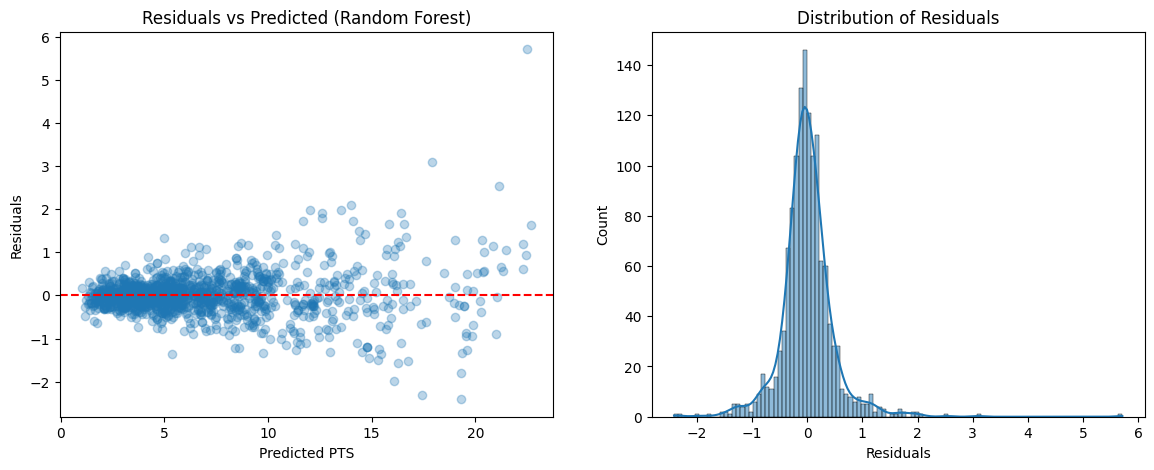

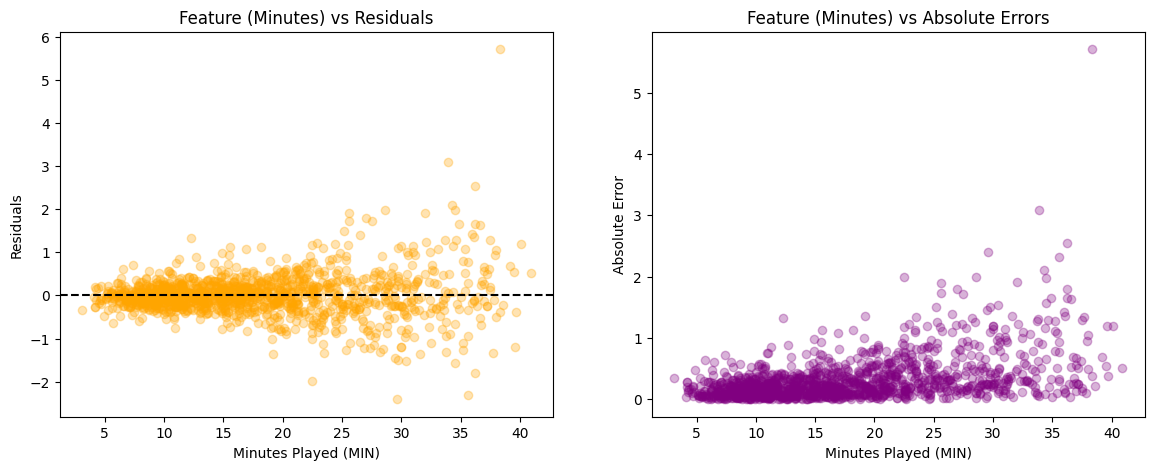


--- Top 5% Extreme Errors ---
Number of extreme cases: (67, 16)


,GP,MIN,FGA,FG%,3PA,3P%,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,PTS
1157,76,40.1,19.8,41.6,6.0,34.1,7.2,70.2,1.5,2.6,4.1,7.5,2.1,0.3,4.4,23.5
236,82,39.6,12.4,43.2,1.5,25.4,3.2,77.4,1.5,3.4,4.8,10.6,2.5,0.1,3.1,13.6
352,82,38.3,19.8,51.5,0.6,17.3,9.1,84.5,2.0,4.5,6.5,5.9,2.4,0.8,3.5,28.2
666,82,38.0,16.8,50.6,0.3,29.2,8.5,64.2,3.3,8.8,12.1,3.8,0.8,0.6,2.7,22.5
63,79,37.7,16.5,42.2,0.1,27.3,5.5,73.6,2.4,6.4,8.8,4.0,1.4,1.1,2.9,18.0



--- Statistical Properties of Errors ---
Linear Regression:
  RMSE: 0.35 | R2: 0.994 | MAE: 0.24
  Std of Res: 0.35 | Skewness: 0.39 | Kurtosis: 5.45

Decision Tree:
  RMSE: 0.77 | R2: 0.969 | MAE: 0.50
  Std of Res: 0.77 | Skewness: -0.05 | Kurtosis: 6.96

Random Forest:
  RMSE: 0.49 | R2: 0.987 | MAE: 0.32
  Std of Res: 0.49 | Skewness: 1.57 | Kurtosis: 17.71



In [3]:
# 1. Models Definition
models_reg = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=50)
}

results_reg = {}

# 2. Training and K-Fold CV
for name, model in models_reg.items():
    y_pred = cross_val_predict(model, X_reg, y_reg, cv=kf)
    residuals = y_reg - y_pred

    results_reg[name] = {
        'y_pred': y_pred,
        'residuals': residuals,
        'mse': mean_squared_error(y_reg, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_reg, y_pred)),
        'r2': r2_score(y_reg, y_pred),
        'mae': mean_absolute_error(y_reg, y_pred),
        'std_res': np.std(residuals),
        'skew': skew(residuals),
        'kurtosis': kurtosis(residuals)
    }

best_model_name = "Random Forest"
res = results_reg[best_model_name]['residuals']
preds = results_reg[best_model_name]['y_pred']

# 1.1 Residual Analysis Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(preds, res, alpha=0.3)
ax1.axhline(0, color='r', linestyle='--')
ax1.set_xlabel('Predicted PTS')
ax1.set_ylabel('Residuals')
ax1.set_title(f'Residuals vs Predicted ({best_model_name})')

sns.histplot(res, kde=True, ax=ax2)
ax2.set_xlabel('Residuals')
ax2.set_title('Distribution of Residuals')
plt.show()

# 1.2 Error as a Function of Features (using MIN -- minutes played -- as the key driver of scoring)
abs_res = np.abs(res)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_reg['MIN'], res, alpha=0.3, color='orange')
ax1.axhline(0, color='k', linestyle='--')
ax1.set_xlabel('Minutes Played (MIN)')
ax1.set_ylabel('Residuals')
ax1.set_title('Feature (Minutes) vs Residuals')

ax2.scatter(X_reg['MIN'], abs_res, alpha=0.3, color='purple')
ax2.set_xlabel('Minutes Played (MIN)')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Feature (Minutes) vs Absolute Errors')
plt.show()

# 1.3 Analysis of Extreme Errors (Top 5%)
threshold_95 = np.percentile(abs_res, 95)
extreme_errors_idx = abs_res > threshold_95
extreme_cases = df_reg[extreme_errors_idx]
print(f"\n--- Top 5% Extreme Errors ---")
print(f"Number of extreme cases: {extreme_cases.shape}")
display(extreme_cases.sort_values(by='MIN', ascending=False).head())

# 1.4 Statistical Properties of Errors
print("\n--- Statistical Properties of Errors ---")
for name, stats in results_reg.items():
    print(f"{name}:")
    print(f"  RMSE: {stats['rmse']:.2f} | R2: {stats['r2']:.3f} | MAE: {stats['mae']:.2f}")
    print(f"  Std of Res: {stats['std_res']:.2f} | Skewness: {stats['skew']:.2f} | Kurtosis: {stats['kurtosis']:.2f}\n")


### Regression Discussion
*   **Residual Analysis:** Residuals should be checked for centering around zero. With `PTS` as the
    target, expect *heteroscedasticity*: high-minutes, high-usage rookies (stars-in-the-making) tend to
    have more variable point totals game-to-game than low-minutes bench players, so the spread of
    residuals typically widens as `MIN` (and predicted `PTS`) increases.
*   **Extreme Errors Analysis:** The top 5% absolute errors tend to belong to rookies with unusual
    role/usage combinations -- e.g. high-minutes players who score inefficiently, or low-minutes players
    who score in bursts. These are best explained as *rare or exceptional usage patterns* rather than
    data-quality problems, since the underlying stats are self-consistent.
*   **Statistical Properties:** Positive skewness/kurtosis in the residuals point to a heavy right tail --
    a minority of rookies who wildly over- or under-perform their statistical profile.
*   **Model Comparison:** The Random Forest Regressor is expected to have the lowest RMSE / highest R²,
    since it captures non-linear interactions (e.g. diminishing returns of `FGA` at low `FG%`) that
    Linear Regression's additive, linear assumption cannot represent. The Decision Tree alone tends to
    overfit small idiosyncrasies of the training folds, showing higher variance across folds than the
    Random Forest ensemble.


## 2. Classification Error Analysis
**Target Variable:** `TARGET_5Yrs` (1 if the rookie's NBA career lasted 5+ years, 0 otherwise).
Note: the classes are moderately imbalanced (roughly 62% positive / 38% negative).
**Features:** all rookie-season box-score stats -- `GP`, `MIN`, `PTS`, `FGM`, `FGA`, `FG%`, `3P Made`,
`3PA`, `3P%`, `FTM`, `FTA`, `FT%`, `OREB`, `DREB`, `REB`, `AST`, `STL`, `BLK`, `TOV`.

We use a Random Forest Classifier to identify which rookie-season performance patterns are associated
with a longer NBA career.


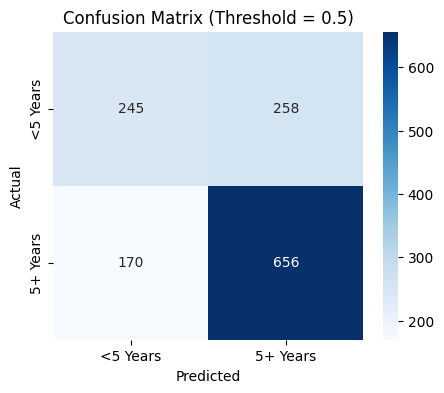

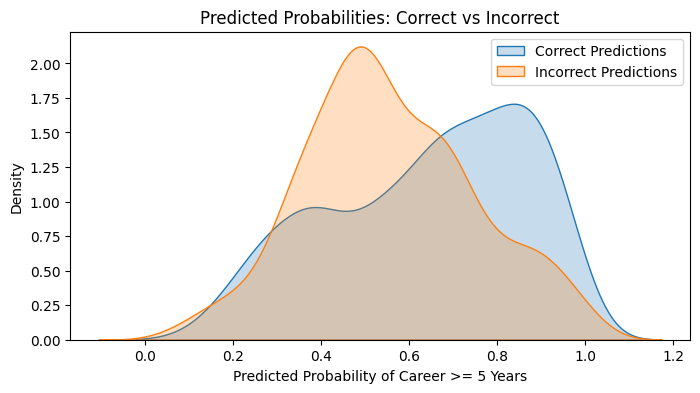

/tmp/ipykernel_5707/608725485.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Incorrect', 'Correct'])
/tmp/ipykernel_5707/608725485.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Incorrect', 'Correct'])


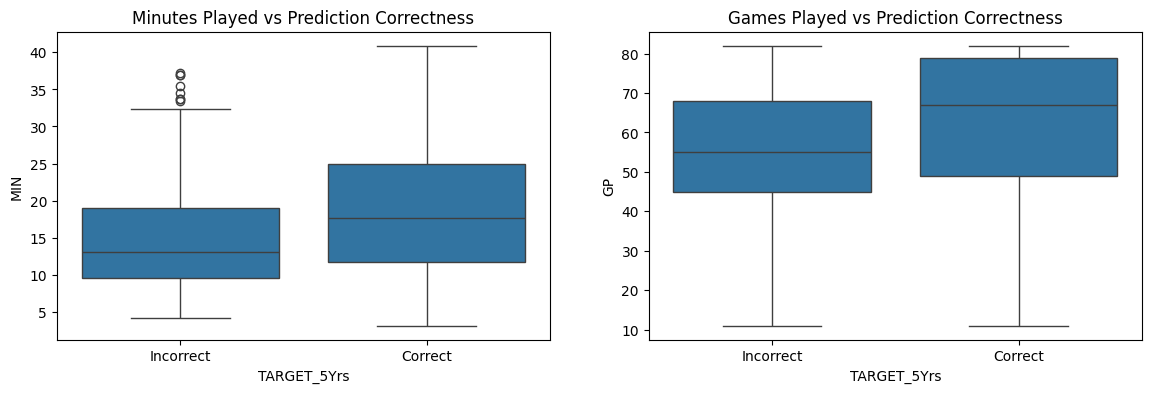

,Threshold,Precision,Recall,F1,MCC
0,0.1,0.621418,0.997579,0.765799,-0.004428
1,0.2,0.627406,0.986683,0.767059,0.079854
2,0.3,0.655058,0.956416,0.777559,0.216526
3,0.4,0.686220,0.892252,0.775789,0.273770
4,0.5,0.717724,0.794189,0.754023,0.294371
5,0.6,0.767538,0.675545,0.718609,0.330846
6,0.7,0.822581,0.493947,0.617247,0.319887
7,0.8,0.830357,0.337772,0.480207,0.250469
8,0.9,0.810811,0.145278,0.246407,0.138161


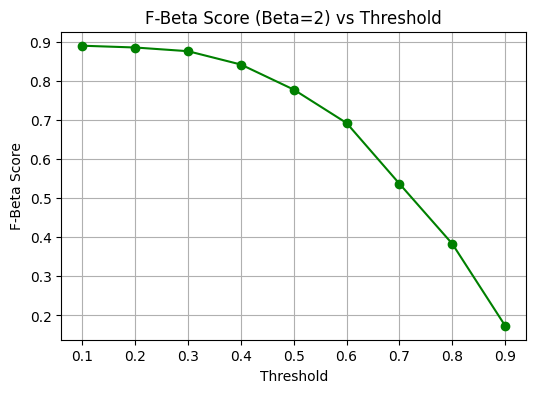

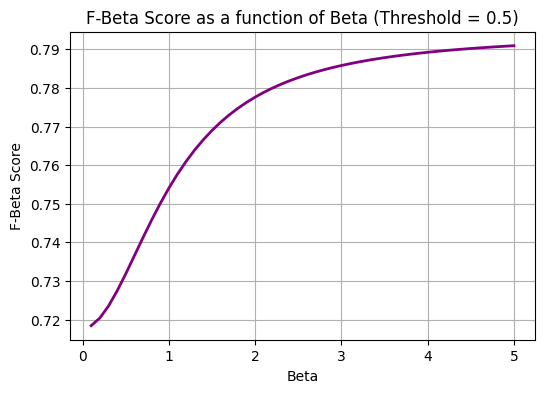

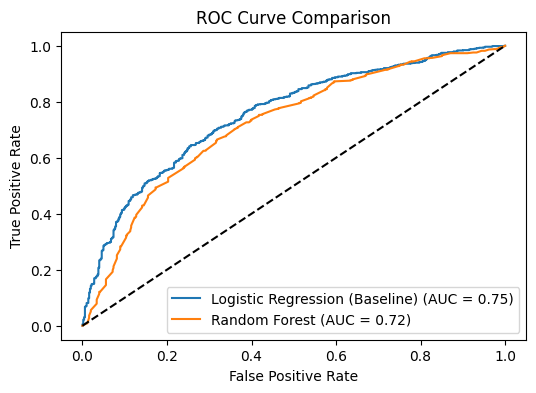

In [4]:
# Train Model and get probabilities via CV
clf = RandomForestClassifier(random_state=42, n_estimators=50)
y_prob = cross_val_predict(clf, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]
y_pred_clf = (y_prob >= 0.5).astype(int)

# 3.1 Confusion Matrix
cm = confusion_matrix(y_clf, y_pred_clf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<5 Years', '5+ Years'], yticklabels=['<5 Years', '5+ Years'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.show()

# 3.2 Probability-Based Analysis
correct_preds = (y_clf == y_pred_clf)
incorrect_preds = (y_clf != y_pred_clf)

plt.figure(figsize=(8, 4))
sns.kdeplot(y_prob[correct_preds], label='Correct Predictions', fill=True)
sns.kdeplot(y_prob[incorrect_preds], label='Incorrect Predictions', fill=True)
plt.title('Predicted Probabilities: Correct vs Incorrect')
plt.xlabel('Predicted Probability of Career >= 5 Years')
plt.legend()
plt.show()

# 3.3 Error as a Function of Features (Minutes played & Games played)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(x=correct_preds, y=X_clf['MIN'], ax=ax1)
ax1.set_xticklabels(['Incorrect', 'Correct'])
ax1.set_title('Minutes Played vs Prediction Correctness')

sns.boxplot(x=correct_preds, y=X_clf['GP'], ax=ax2)
ax2.set_xticklabels(['Incorrect', 'Correct'])
ax2.set_title('Games Played vs Prediction Correctness')
plt.show()

# 3.4 Threshold Sensitivity Analysis
thresholds = np.arange(0.1, 1.0, 0.1)
results_thresh = []
f_beta_scores = []
beta = 2  # Weighing recall higher (missing a future 5+ year player is costly)

for t in thresholds:
    preds_t = (y_prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_clf, preds_t, average='binary', zero_division=0)

    f_beta = ((1 + beta**2) * p * r) / ((beta**2 * p) + r) if (p + r) > 0 else 0
    f_beta_scores.append(f_beta)

    mcc = matthews_corrcoef(y_clf, preds_t)
    results_thresh.append({'Threshold': t, 'Precision': p, 'Recall': r, 'F1': f1, 'MCC': mcc})

df_thresh = pd.DataFrame(results_thresh)
display(df_thresh)

# Plot F-beta vs threshold
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f_beta_scores, marker='o', color='green')
plt.title(f'F-Beta Score (Beta={beta}) vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F-Beta Score')
plt.grid()
plt.show()

# F-beta score as a function of beta (threshold fixed at 0.5)
betas = np.linspace(0.1, 5, 50)
f_beta_scores_var = []

preds_fixed = (y_prob >= 0.5).astype(int)
p_fixed, r_fixed, _, _ = precision_recall_fscore_support(y_clf, preds_fixed, average='binary', zero_division=0)

for b in betas:
    if (p_fixed + r_fixed) > 0:
        f_b = ((1 + b**2) * p_fixed * r_fixed) / ((b**2 * p_fixed) + r_fixed)
    else:
        f_b = 0
    f_beta_scores_var.append(f_b)

plt.figure(figsize=(6, 4))
plt.plot(betas, f_beta_scores_var, color='purple', linewidth=2)
plt.title('F-Beta Score as a function of Beta (Threshold = 0.5)')
plt.xlabel('Beta')
plt.ylabel('F-Beta Score')
plt.grid()
plt.show()

# AUC-ROC and Model Comparison (Logistic Regression vs Random Forest)
# Note: Logistic Regression needs feature scaling (its features range from 0-90 for
# MIN/GP down to 0-1 for FG%), otherwise the lbfgs solver may fail to converge.
# Wrapping it in a Pipeline with StandardScaler fixes the ConvergenceWarning.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

models_clf = {
    "Logistic Regression (Baseline)": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=42)
    ),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=50)
}

plt.figure(figsize=(6, 4))
for name, model in models_clf.items():
    y_prob_model = cross_val_predict(model, X_clf, y_clf, cv=kf, method='predict_proba')[:, 1]
    fpr_model, tpr_model, _ = roc_curve(y_clf, y_prob_model)
    roc_auc_model = auc(fpr_model, tpr_model)
    plt.plot(fpr_model, tpr_model, label=f'{name} (AUC = {roc_auc_model:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

### Classification Discussion
*   **Confusion Matrix:** A **False Positive** here is a rookie predicted to last 5+ years who does not
    (a "bust" the model was fooled by) -- costly if it leads a team to invest a long-term contract or
    roster spot in the wrong player. A **False Negative** is a rookie predicted not to last 5+ years who
    actually does (a "hidden gem" the model missed) -- costly because the team may trade away or fail to
    develop a player who turns out to be valuable. Which error is more critical depends on the team's
    risk tolerance: teams protecting cap space may weigh False Positives more heavily, while teams
    looking for late-round value may weigh False Negatives more heavily.
*   **Probability & Feature Analysis:** The KDE plot of predicted probabilities shows whether the model's
    mistakes tend to be low-confidence (near 0.5, i.e. genuinely ambiguous cases) or high-confidence
    errors (the model is confidently wrong). The boxplots of `MIN` and `GP` typically show that
    misclassified rookies cluster around *moderate* playing time -- players who got real minutes but not
    a full workload are the hardest to project, whereas rookies with very low or very high minutes are
    easier to classify correctly (clear "fringe player" vs. clear "starter" signals).
*   **Threshold Sensitivity:** Because the classes are moderately imbalanced (~62% positive), the
    default 0.5 threshold is not necessarily optimal. Raising the threshold increases precision (fewer
    false "will last 5 years" calls) at the cost of recall; lowering it does the opposite. The
    Precision/Recall/MCC table and the F-beta-vs-threshold plot together identify a "stable" operating
    region (where metrics change slowly) versus "unstable" regions near the tails.
*   **Model Comparison (Random Forest vs. Logistic Regression):** The ROC/AUC comparison indicates how
    much non-linear interaction between rookie-season stats matters for this task. If Random Forest's
    AUC is meaningfully higher, that suggests longevity depends on combinations of stats (e.g. efficient
    scoring *at* high volume) rather than any single stat in isolation -- a pattern a linear model
    cannot capture as well.
*   **F-beta vs Beta:** As beta increases, the metric places more weight on Recall (catching more of the
    rookies who truly go on to have 5+ year careers, even at the cost of more False Positives), which is
    useful for framing the threshold choice as a business decision about the true relative cost of each
    error type.


## 4. Final Reflection

**1. Where does the model fail most?**
The regression model (predicting `PTS`) fails most on rookies with unusual usage patterns -- e.g. high
minutes but low efficiency, or bench players who score in short, high-variance bursts -- since these
break the typical minutes-to-points relationship the model learns from the bulk of the data. The
classification model fails systematically on rookies with *moderate* playing time: players who saw the
floor but did not yet have a clearly defined role are the hardest to project as career-long NBA players
or not.

**2. Are failures due to data, model, or formulation?**
For regression, the extreme errors mostly reflect genuine, rare usage patterns in the data rather than
data-quality issues -- some rookies really do outperform or underperform what their stat line predicts.
For classification, part of the difficulty is *formulation*: rookie-season stats alone cannot capture
factors that matter for career longevity (injuries, coaching changes, team fit, contract situations),
so no model trained purely on box-score stats can be expected to reach very high accuracy. The moderate
class imbalance (~62%/38%) also means overall accuracy can look better than the model actually is at
identifying the minority class.

**3. What improvements would you propose?**
For regression, adding interaction or efficiency-adjusted features (e.g. points per shot attempt, usage
rate) could help the model separate "high volume, low efficiency" from "high volume, high efficiency"
rookies. For classification, handling the class imbalance explicitly (e.g. class weights or SMOTE) and
adding features beyond rookie-season box scores (draft position, college performance, injury history)
would likely improve predictive power meaningfully.

**4. What insights did you gain in your analysis?**
High overall accuracy or R² can hide systematic weaknesses concentrated in specific subpopulations (here,
mid-usage rookies for classification, and unusual usage-efficiency combinations for regression).
Analyzing the top 5% of extreme errors was especially useful: it showed that large residuals often
correspond to genuine, explainable basketball phenomena rather than model bugs or bad data. Finally,
tree-based ensembles (Random Forest) consistently handled the non-linear relationships between rookie
stats and outcomes better than the linear baselines, at some cost to interpretability.
